<a href="https://colab.research.google.com/github/mateoveega/MCMC-MonteCarlo-TFG/blob/main/CH_3/cybersecurity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import sys
import importlib

repo_name = 'MCMC-MonteCarlo-TFG'
repo_url = f'https://github.com/mateoveega/{repo_name}.git'
repo_path = f'/content/{repo_name}'

if not os.path.exists(repo_path):
    !git clone {repo_url}
else:
    %cd {repo_path}
    !git pull
    %cd /content

if repo_path not in sys.path:
    sys.path.append(repo_path)

import samplers
importlib.reload(samplers)
from samplers import metropolis_hastings_log, composite_transition
from collections import Counter
from scipy.sparse.csgraph import shortest_path

import numpy as np
import matplotlib.pyplot as plt
import random
import networkx as nx

Cloning into 'MCMC-MonteCarlo-TFG'...
remote: Enumerating objects: 254, done.
remote: Counting objects: 100% (109/109), done.
remote: Compressing objects: 100% (105/105), done.
remote: Total 254 (delta 61), reused 4 (delta 4), pack-reused 145 (from 1)
Receiving objects: 100% (254/254), 5.52 MiB | 13.08 MiB/s, done.
Resolving deltas: 100% (122/122), done.


In [2]:
rng = np.random.default_rng(seed = 1)

num_nodes = 5000

# Simulamos la topología de internet/corporativa usando Watts-Strogatz
# k: Cada nodo se conecta a sus 'k' vecinos más cercanos (debe ser un número par)
# p: Probabilidad de reconectar un cable al azar (crea los puentes entre departamentos)
G = nx.watts_strogatz_graph(n = num_nodes, k = 4, p = 0.02, seed = 1)

# Calculamos las distancias más cortas entre todos los pares de nodos

adj_matrix = nx.to_scipy_sparse_array(G)
dist_matrix = shortest_path(csgraph = adj_matrix, directed = False, method = 'D')

# Simulamos la infección real
real_patient_zero = random.choice(list(G.nodes()))
propagation_speed = 2 # Tiempo que tarda en saltar de un nodo a otro (constante)

# Tiempos teóricos de infección para toda la red
real_infection_times = dist_matrix[real_patient_zero, :] * propagation_speed

# Visibilidad Parcial (El equipo de seguridad solo ve una parte)
observation_ratio = 0.02 # Solo tienen antivirus/logs el 2% de las máquinas
observed_nodes = random.sample(list(G.nodes()), int(num_nodes * observation_ratio))

# Añadimos un poco de ruido a las alarmas (retrasos de red, etc.)
loc = 0
scale = 0.5
observed_times = {node: max(0, real_infection_times[node] + rng.normal(loc, scale)) for node in observed_nodes}

obs_indices = np.array(list(observed_times.keys()))
obs_values = np.array(list(observed_times.values()))

In [3]:
# Para el "Salto Dirigigo por los Datos", calculamos una probabilidad basada en:
# 1. Nodos que se infectaron muy pronto (bajos observed_times)
# 2. Centralidad (nodos que actúan como puentes)

centrality_dict = nx.degree_centrality(G)
centrality_values = np.array([centrality_dict[i] for i in range(num_nodes)])

observed_indices = list(observed_nodes)

min_dists = np.min(dist_matrix[:, observed_indices], axis=1)

proximity_weights = 1.0 / (1.0 + min_dists)
jump_probabilities = centrality_values * proximity_weights
jump_probabilities = jump_probabilities / np.sum(jump_probabilities)

In [4]:
def log_target_pdf(current_state):
    dists = dist_matrix[current_state, obs_indices]
    theoretical_times = dists * propagation_speed
    total_error = np.sum((obs_values - theoretical_times)**2)

    return - total_error / (2 * scale**2)

def guided_sampler(current_node, rng):
    return rng.choice(G.nodes(), p = jump_probabilities)

def random_walk_sampler(current_node, rng):
    neighbors = list(G.neighbors(current_node))
    return rng.choice(neighbors)

# Generamos la propuesta usando la composición de transiciones
base_transitions = [random_walk_sampler, guided_sampler]
alphas = [0.85, 0.15]
proposal_sampler = composite_transition(base_transitions, alphas)

def log_proposal_pdf(proposed_state, current_state, alpha_guided = 0.15):
    p_guided = jump_probabilities[proposed_state]
    current_neighbors = list(G.neighbors(current_state))

    if proposed_state in current_neighbors:
        p_rw = 1.0 / len(current_neighbors)
    else:
        p_rw = 0.0

    p_total = (alpha_guided * p_guided) + ((1.0 - alpha_guided) * p_rw)
    eps = 1e-12

    return np.log(p_total + eps)

# --- NUEVA FUNCIÓN: Templado Simulado (Simulated Annealing) ---
def simulated_annealing_log(initial_state, log_target, sampler, log_proposal, iters, T0=100.0, gamma=0.9995, seed=1):
    rng = np.random.default_rng(seed)
    current_state = initial_state
    current_log_p = log_target(current_state)

    state_hist = []
    energy_hist = []
    T = T0

    for i in range(iters):
        proposed_state = sampler(current_state, rng)
        proposed_log_p = log_target(proposed_state)

        # Evaluamos la asimetría de las propuestas globales
        log_q_forward = log_proposal(proposed_state, current_state)
        log_q_backward = log_proposal(current_state, proposed_state)

        # Ratio de aceptación logarítmico (Delta E)
        log_alpha = (proposed_log_p - current_log_p) + (log_q_backward - log_q_forward)

        # Aplicamos la Temperatura (Templado Simulado)
        # Si log_alpha > 0, es un estado mejor (Energía menor), se acepta siempre.
        # Si log_alpha < 0, es un estado peor. Al dividir por T, permitimos
        # explorarlo más fácilmente cuando T es alta.
        if log_alpha > 0:
            log_alpha_T = 0.0
        else:
            log_alpha_T = log_alpha / T

        # Criterio de aceptación
        if np.log(rng.random()) <= log_alpha_T:
            current_state = proposed_state
            current_log_p = proposed_log_p

        state_hist.append(current_state)
        energy_hist.append(-current_log_p) # Guardamos la energía real

        # Enfriamiento exponencial
        T = max(T * gamma, 1e-5) # Límite inferior para evitar inestabilidad numérica

    return current_state, energy_hist, state_hist

# --- EJECUCIÓN DEL MODELO ---
initial_node = rng.choice(G.nodes())
num_iterations = 15000

# Llamamos a nuestra nueva función de Templado Simulado en lugar de MH estándar
inferred_node, energy_history, state_history = simulated_annealing_log(
    initial_state = initial_node,
    log_target = log_target_pdf,
    sampler = proposal_sampler,
    log_proposal = log_proposal_pdf,
    iters = num_iterations,
    T0 = 100.0,       # Temperatura inicial (Mencionada en el LaTeX)
    gamma = 0.9992    # Factor de enfriamiento
)

Nodo Cero Real     : 984
Nodo Cero Inferido : 984
Distancia en saltos entre inferido y real: 0.0


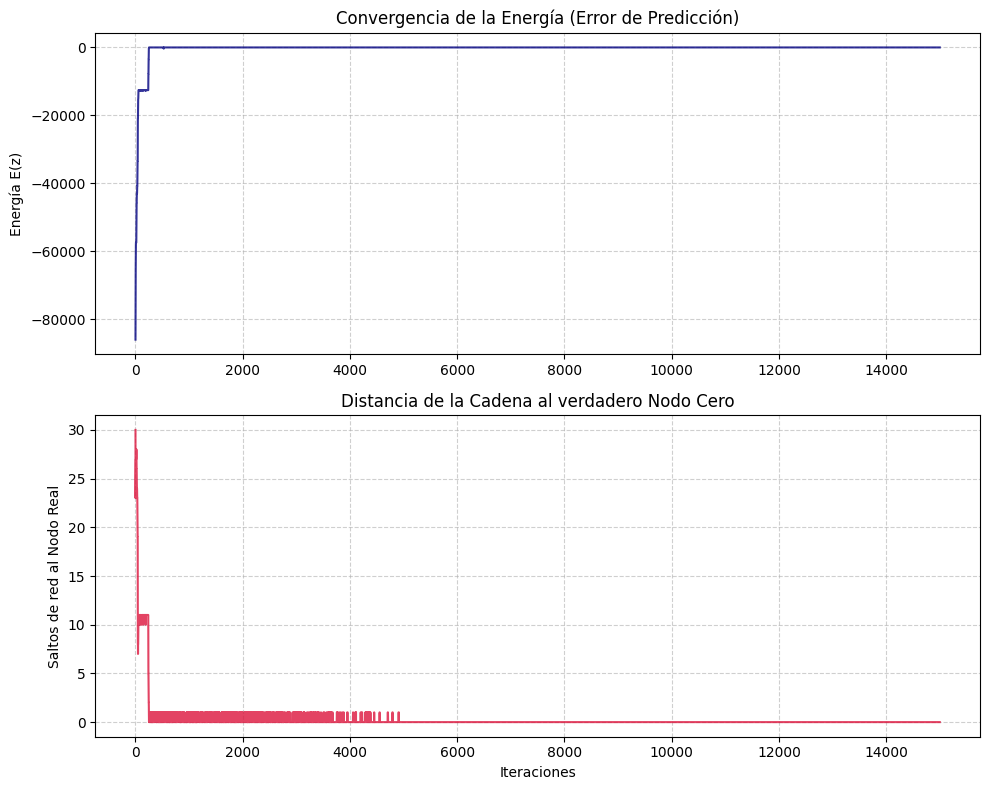

In [5]:
print(f"Nodo Cero Real     : {real_patient_zero}")
print(f"Nodo Cero Inferido : {inferred_node}")
print(f"Distancia en saltos entre inferido y real: {dist_matrix[inferred_node, real_patient_zero]}")

# Calcular el historial de distancias a partir del historial de estados
distance_history = dist_matrix[state_history, real_patient_zero]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Gráfica 1: Energía (Trace plot de la log-verosimilitud)
ax1.plot(- np.array(energy_history), color='navy', alpha=0.8)
ax1.set_title('Convergencia de la Energía (Error de Predicción)', fontsize=12)
ax1.set_ylabel('Energía E(z)')
ax1.grid(True, linestyle='--', alpha=0.6)

# Gráfica 2: Precisión real (Distancia al verdadero Patient Zero)
ax2.plot(distance_history, color='crimson', alpha=0.8)
ax2.set_title('Distancia de la Cadena al verdadero Nodo Cero', fontsize=12)
ax2.set_xlabel('Iteraciones')
ax2.set_ylabel('Saltos de red al Nodo Real')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('CIBERSEGURIDAD.pdf')
plt.show()

In [6]:
from google.colab import files
files.download("CIBERSEGURIDAD.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>